# Distancia mínima recorrida (20 m) — loops y error de traslación

Comparación contra [02_pnp_rectificado](../02_pnp_rectificado/), que ya tiene el PnP arreglado. Lo único que cambia es la exclusión:
en vez de no matchear contra las imágenes de los últimos 20 s (`dislocal`), solo se matchea contra imágenes desde las que el
robot recorrió al menos 20 m (`--min-distance 20`, medido sobre las poses).

Con la ventana temporal, un robot detenido más de 20 s se matchea consigo mismo: esos loops son correctos pero no aportan
nada a la corrección de la trayectoria. Con la distancia mínima desaparecen. Como los loops cambian, la comparación no es
pareada.

Error de cada loop: $e = |\,\|t_{est}\| - \|p_{gps}(q) - p_{gps}(m)\|\,|$ (ver [02_pnp_rectificado](../02_pnp_rectificado/)).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')  # evaluation/, donde está commons.py
from commons import load_results, load_ground_truth, translation_errors

RUNS = {  # etiqueta -> carpeta con los .yml de la corrida
    'Ventana de 20 s': Path('../02_pnp_rectificado'),
    'Distancia mínima 20 m': Path('.'),
}
PREPARED = Path('/mnt/datalake/datasets/fieldsafe/prepared')
SESSIONS = {  # nombre -> (clave del archivo, sesión de FieldSAFE)
    'Dinámica #1': ('dynamic1', '2016-10-25-11-41-21'),
    'Estática #1': ('static1', '2016-10-25-11-09-42'),
    'Dinámica #2': ('dynamic2', '2016-10-25-12-07-22'),
}
FAR_M = 5.0  # loops con query y match a más de esto según el GPS: no son el mismo lugar

In [2]:
data = {}  # sesión -> dict con xy y, por corrida, los loops
for label, (key, session) in SESSIONS.items():
    runs = {}
    for run, folder in RUNS.items():
        res, q, m, t_est = load_results(folder / f'fs_{key}_results.yml')
        xy = load_ground_truth(PREPARED / f'poses_{session}.csv', num_images=res['num_images'])
        err, stopped = translation_errors(xy, q, m, t_est)
        gt = np.linalg.norm(xy[q] - xy[m], axis=1)
        runs[run] = dict(res=res, q=q, m=m, err=err, stopped=stopped, gt=gt)
    data[label] = dict(xy=xy, runs=runs)

print(f"{'Sesión':<12} {'Corrida':<22} {'loops':>6} {'detenido':>9} {'en mov.':>8} {f'Δp>{FAR_M:g} m':>9}")
for label, d in data.items():
    for run, r in d['runs'].items():
        print(f"{label:<12} {run:<22} {len(r['q']):6d} {r['stopped'].sum():9d} {(~r['stopped']).sum():8d} "
              f"{(r['gt'] > FAR_M).sum():9d}")

Sesión       Corrida                 loops  detenido  en mov.    Δp>5 m
Dinámica #1  Ventana de 20 s           197       136       61         0
Dinámica #1  Distancia mínima 20 m      55         0       55         0
Estática #1  Ventana de 20 s           198       187       11         0
Estática #1  Distancia mínima 20 m       0         0        0         0
Dinámica #2  Ventana de 20 s           122       122        0         0
Dinámica #2  Distancia mínima 20 m       0         0        0         0


## Dónde están los loops

Trayectoria GPS de cada sesión y, encima, los loops detectados: una línea de match a query y un punto en la query.

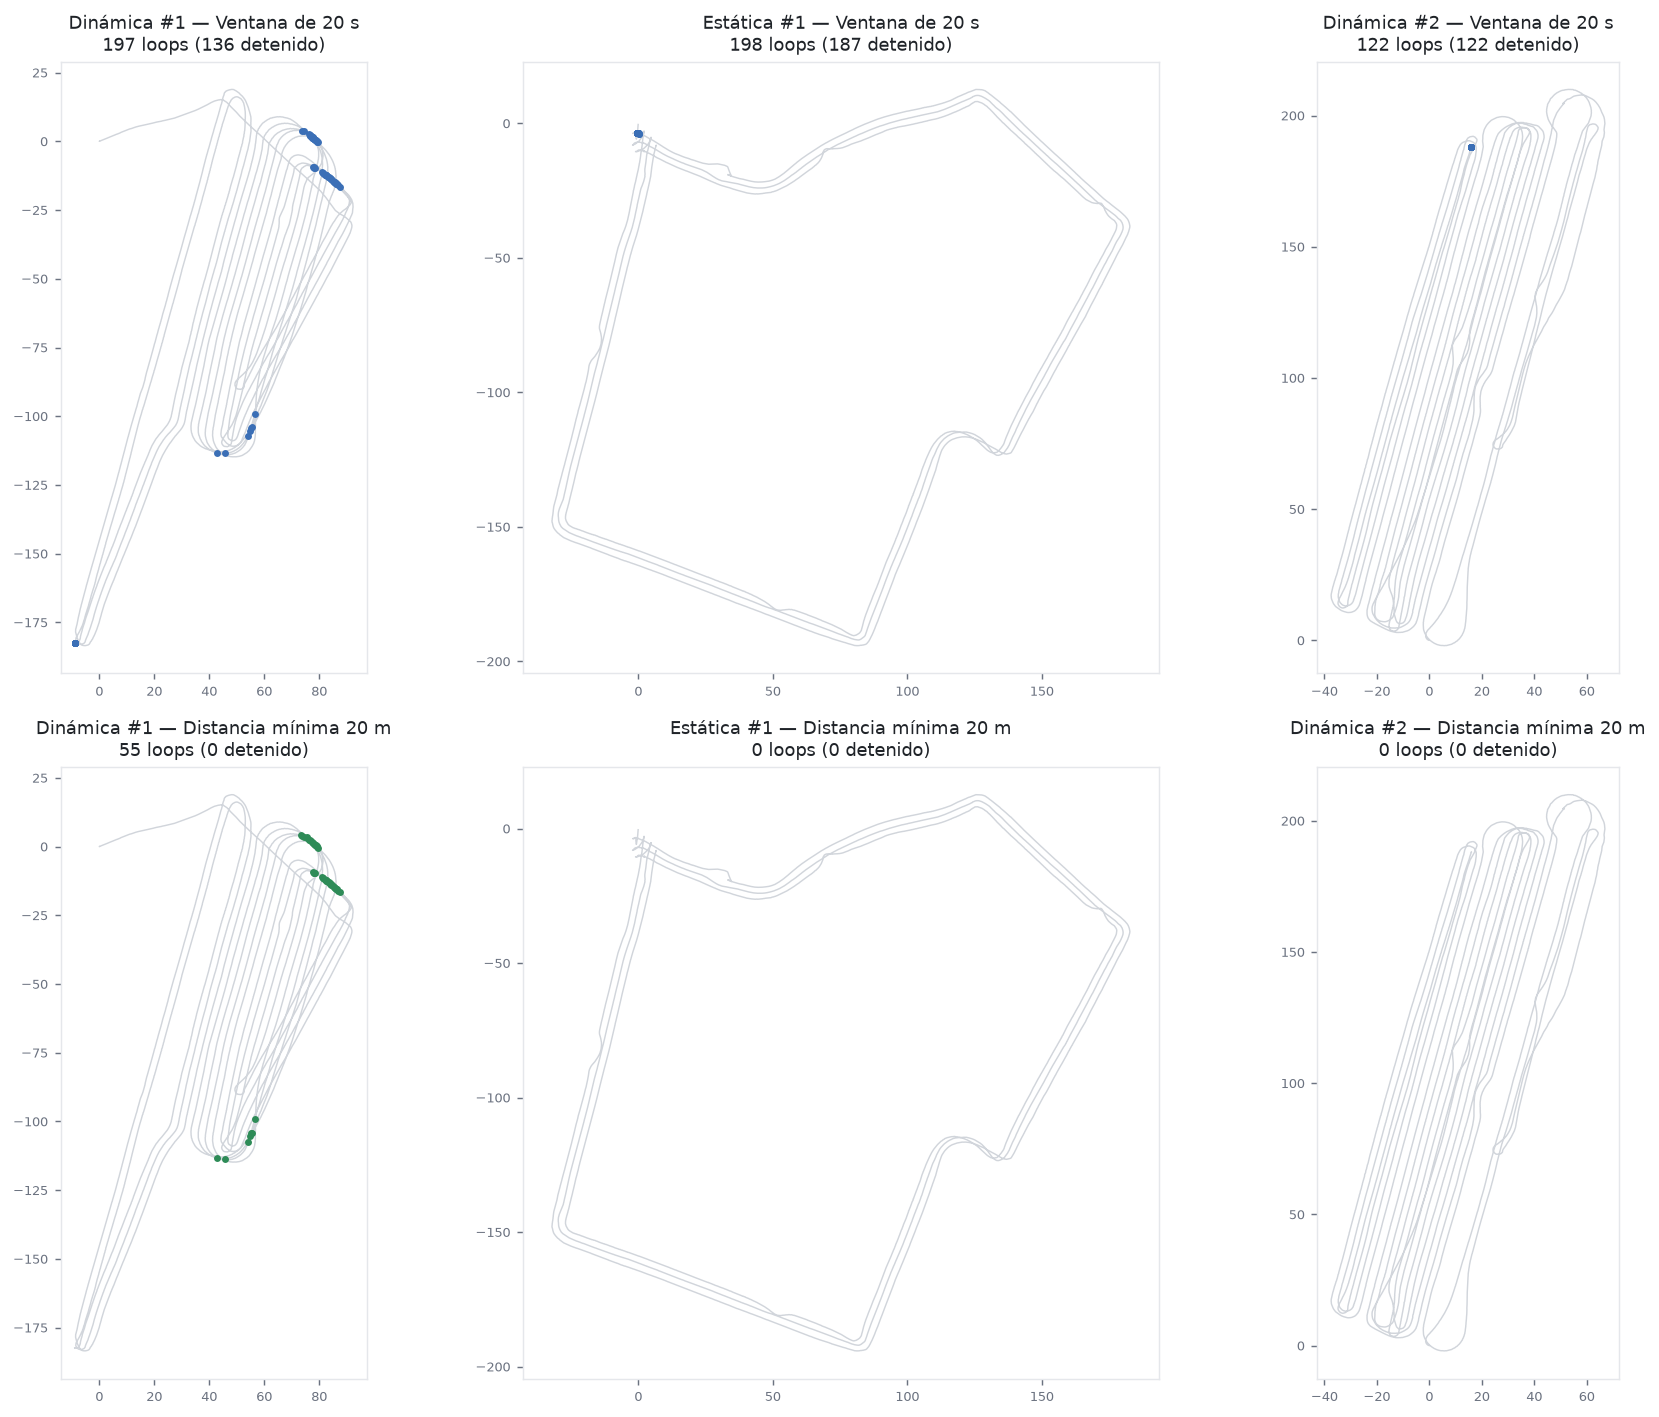

In [3]:
COLORS = {'Ventana de 20 s': '#3b6fb6', 'Distancia mínima 20 m': '#2e8b57'}
ink, muted = '#1f2328', '#6b7280'

fig, axes = plt.subplots(len(RUNS), len(data), figsize=(5 * len(data), 5.5 * len(RUNS)), dpi=130)
for col, (label, d) in enumerate(data.items()):
    xy = d['xy']
    for row, (run, r) in enumerate(d['runs'].items()):
        ax = axes[row, col]
        ax.plot(xy[:, 0], xy[:, 1], color='#d1d5db', linewidth=0.8, zorder=1)
        for qi, mi in zip(r['q'], r['m']):
            ax.plot(xy[[mi, qi], 0], xy[[mi, qi], 1], color=COLORS[run], linewidth=0.8, alpha=0.6, zorder=2)
        ax.scatter(xy[r['q'], 0], xy[r['q'], 1], s=8, color=COLORS[run], zorder=3)
        ax.set_aspect('equal')
        ax.set_title(f"{label} — {run}\n{len(r['q'])} loops ({r['stopped'].sum()} detenido)", fontsize=10, color=ink)
        ax.tick_params(colors=muted, labelsize=7)
        for s in ax.spines.values():
            s.set_color('#e5e7eb')
fig.tight_layout()
fig.savefig('loops_map.png', bbox_inches='tight')

## Error de traslación

Solo los loops en movimiento: los detenidos ya se analizaron en [02_pnp_rectificado](../02_pnp_rectificado/) y con la distancia
mínima no existen.

In [4]:
def stats_row(e):
    if not len(e):
        return f"{0:4d} {'—':>10} {'—':>12} {'—':>8} {'—':>8}"
    return f"{len(e):4d} {e.mean():10.3f} {np.median(e):12.3f} {np.percentile(e, 90):8.3f} {e.max():8.3f}"

print(f"{'Sesión':<12} {'Corrida':<22} {'n':>4} {'media [m]':>10} {'mediana [m]':>12} {'p90 [m]':>8} {'max [m]':>8}")
for label, d in data.items():
    for run, r in d['runs'].items():
        print(f"{label:<12} {run:<22} {stats_row(r['err'][~r['stopped']])}")

Sesión       Corrida                   n  media [m]  mediana [m]  p90 [m]  max [m]
Dinámica #1  Ventana de 20 s          61      0.084        0.051    0.205    0.378
Dinámica #1  Distancia mínima 20 m    55      0.107        0.049    0.225    1.557
Estática #1  Ventana de 20 s          11      0.713        0.033    0.174    7.391
Estática #1  Distancia mínima 20 m     0          —            —        —        —
Dinámica #2  Ventana de 20 s           0          —            —        —        —
Dinámica #2  Distancia mínima 20 m     0          —            —        —        —


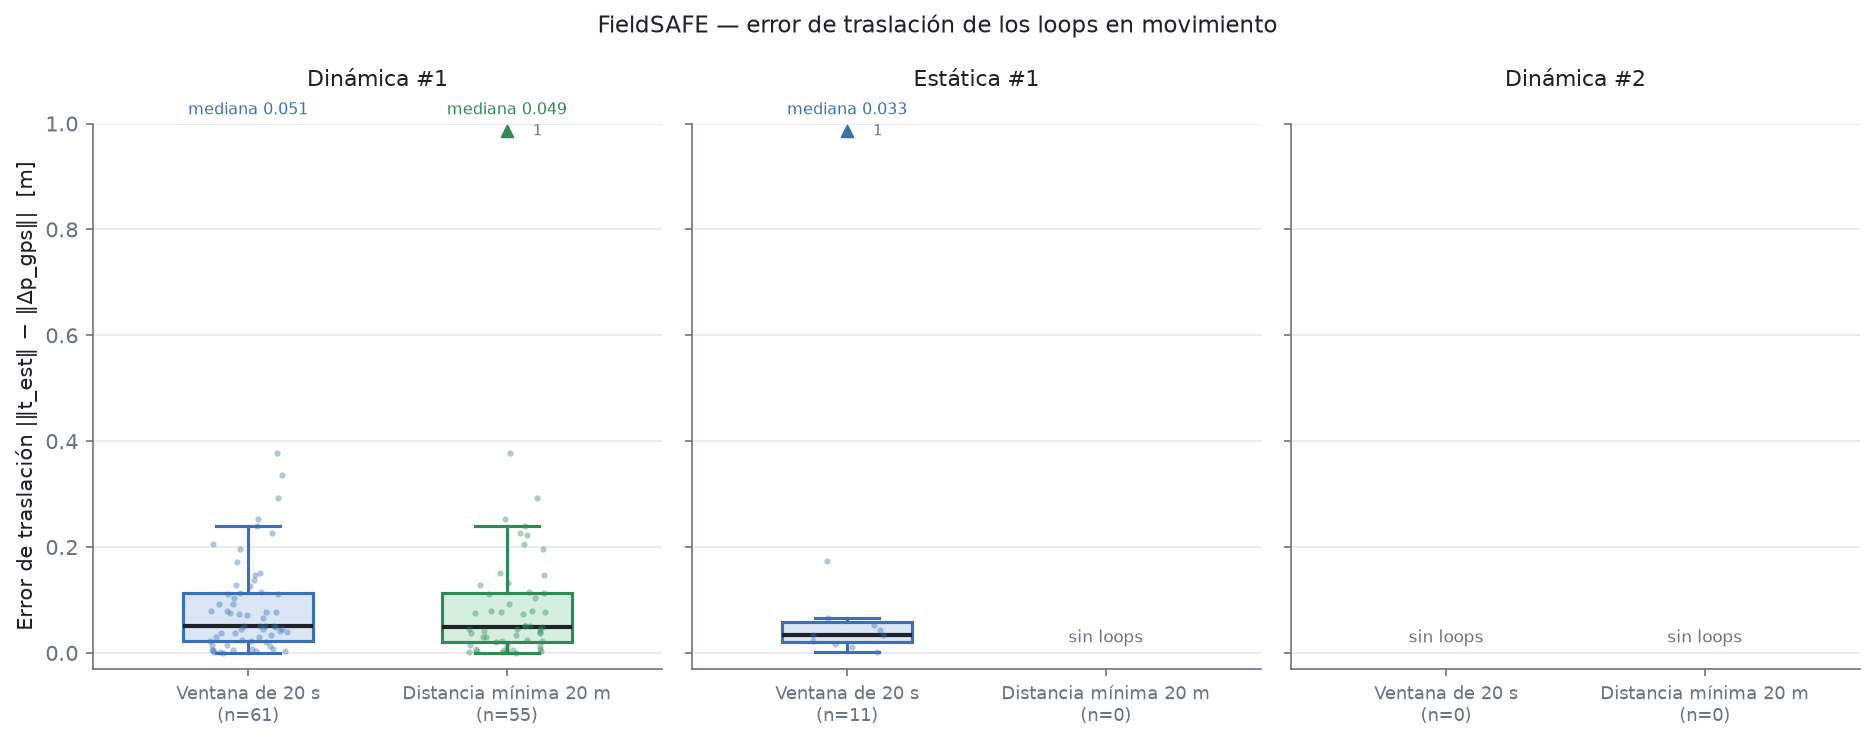

In [5]:
FILL = {'Ventana de 20 s': '#dbe6f5', 'Distancia mínima 20 m': '#d6eee0'}
Y_MAX = 1.0  # m
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(data), figsize=(4.2 * len(data), 5), dpi=150, sharey=True)
for ax, (label, d) in zip(axes, data.items()):
    for x, (run, r) in enumerate(d['runs'].items(), start=1):
        e = r['err'][~r['stopped']]
        if not len(e):
            ax.text(x, 0.02, 'sin loops', ha='center', fontsize=8, color=muted)
            continue
        ax.boxplot([e], positions=[x], widths=0.5, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor=FILL[run], edgecolor=COLORS[run], linewidth=1.5),
                   medianprops=dict(color=ink, linewidth=2),
                   whiskerprops=dict(color=COLORS[run], linewidth=1.5),
                   capprops=dict(color=COLORS[run], linewidth=1.5))
        inside = e <= Y_MAX
        jitter = x + rng.uniform(-0.15, 0.15, len(e))
        ax.scatter(jitter[inside], e[inside], s=9, color=COLORS[run], alpha=0.4, linewidths=0, zorder=3)
        if (~inside).any():
            ax.scatter([x], [Y_MAX * 0.985], marker='^', s=30, color=COLORS[run], zorder=3, clip_on=False)
            ax.annotate(f"{(~inside).sum()}", (x + 0.1, Y_MAX * 0.985), fontsize=7, color=muted, va='center')
        ax.annotate(f"mediana {np.median(e):.3f}", (x, 1.01), xycoords=('data', 'axes fraction'), ha='center',
                    va='bottom', fontsize=7.5, color=COLORS[run], annotation_clip=False)
    ax.set_xticks([1, 2], [f"{run}\n(n={(~r['stopped']).sum()})" for run, r in d['runs'].items()], fontsize=8.5)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylim(-0.03, Y_MAX)
    ax.set_title(label, fontsize=10.5, color=ink, pad=18)
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(muted)
    ax.tick_params(colors=muted)
axes[0].set_ylabel('Error de traslación |‖t_est‖ − ‖Δp_gps‖|  [m]', color=ink)
fig.suptitle('FieldSAFE — error de traslación de los loops en movimiento', fontsize=11, color=ink)
fig.tight_layout()
fig.savefig('translation_error_boxplot.png', bbox_inches='tight')

## Conclusiones

- **Desaparecen los loops del robot detenido** (445 de 517 con la ventana de 20 s). Era lo esperado: con la exclusión
  temporal, el detector se matcheaba consigo mismo después de 20 s quieto.
- **Estática #1 y Dinámica #2 quedan sin loops.** En Dinámica #2 todos eran con el robot detenido. Los 11 "en movimiento"
  de Estática #1 tenían solo 1–2 m de recorrido entre match y query (el robot avanzaba muy despacio): tampoco eran
  revisitas.
- **Dinámica #1 queda con 55 loops reales**, todos con más de 229 m recorridos entre match y query. 52 son los mismos
  pares que con la ventana de 20 s y 3 son nuevos (al cambiar la exclusión cambia qué candidatos pasan la consistencia
  temporal). La mediana del error de traslación es la misma (0,049 vs 0,051 m).
- Las tres sesiones tienen miles de frames que revisitan un lugar (ver la trayectoria), así que la cobertura de
  StereoLoopDetector original en FieldSAFE es muy baja: los loops verdaderos están concentrados en unos pocos tramos de
  Dinámica #1.